# The Evolution of NLP – Comparing Three Eras of Sentiment Analysis

### Course: Natural Language Processing

**Objective**

This project compares three different approaches for sentiment analysis on movie reviews:

- Traditional Machine Learning (TF-IDF + Logistic Regression)
- Deep Learning (PyTorch LSTM)
- Pretrained NLP Model (NLTK VADER)

The comparison evaluates their accuracy, F1-score, training time, and practical suitability for deployment in a real-world business environment.

# Task 1: Data Sourcing & Preprocessing

In [48]:
# ================================
# Import Required Libraries
# ================================

import re
import string
import time
import random

import numpy as np
import pandas as pd

import nltk

from nltk.corpus import movie_reviews
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_colwidth", 150)

In [49]:
# ================================
# Download Required NLTK Resources
# ================================

nltk.download("movie_reviews")
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("vader_lexicon")

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [50]:
# ================================
# Load Movie Reviews Dataset
# ================================

documents = []

for category in movie_reviews.categories():
    for fileid in movie_reviews.fileids(category):
        review = movie_reviews.raw(fileid)
        documents.append((review, category))

# Create DataFrame
df = pd.DataFrame(documents, columns=["Review", "Sentiment"])

# Display first five rows
df.head()

,Review,Sentiment
0,"plot : two teen couples go to a church party , drink and then drive . \nthey get into an accident . \none of the guys dies , but his girlfriend co...",neg
1,the happy bastard's quick movie review \ndamn that y2k bug . \nit's got a head start in this movie starring jamie lee curtis and another baldwin b...,neg
2,it is movies like these that make a jaded movie viewer thankful for the invention of the timex indiglo watch . \nbased on the late 1960's televisi...,neg
3,""" quest for camelot "" is warner bros . ' first feature-length , fully-animated attempt to steal clout from disney's cartoon empire , but the mous...",neg
4,synopsis : a mentally unstable man undergoing psychotherapy saves a boy from a potentially fatal accident and then falls in love with the boy's mo...,neg


In [51]:
print("Dataset Shape:", df.shape)

print("\nSentiment Distribution")
print(df["Sentiment"].value_counts())

Dataset Shape: (2000, 2)

Sentiment Distribution
Sentiment
neg    1000
pos    1000
Name: count, dtype: int64


In [52]:
print(df.isnull().sum())

Review       0
Sentiment    0
dtype: int64


In [53]:
print("Positive Review\n")
print(df[df["Sentiment"]=="pos"]["Review"].iloc[0])

print("\n\n--------------------------------------------\n")

print("Negative Review\n")
print(df[df["Sentiment"]=="neg"]["Review"].iloc[0])

Positive Review

films adapted from comic books have had plenty of success , whether they're about superheroes ( batman , superman , spawn ) , or geared toward kids ( casper ) or the arthouse crowd ( ghost world ) , but there's never really been a comic book like from hell before . 
for starters , it was created by alan moore ( and eddie campbell ) , who brought the medium to a whole new level in the mid '80s with a 12-part series called the watchmen . 
to say moore and campbell thoroughly researched the subject of jack the ripper would be like saying michael jackson is starting to look a little odd . 
the book ( or " graphic novel , " if you will ) is over 500 pages long and includes nearly 30 more that consist of nothing but footnotes . 
in other words , don't dismiss this film because of its source . 
if you can get past the whole comic book thing , you might find another stumbling block in from hell's directors , albert and allen hughes . 
getting the hughes brothers to direct this

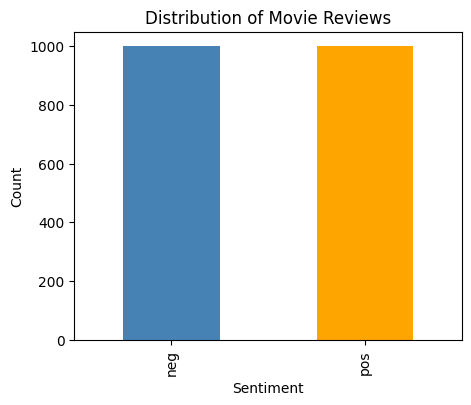

In [54]:
plt.figure(figsize=(5,4))

df["Sentiment"].value_counts().plot(
    kind="bar",
    color=["steelblue", "orange"]
)

plt.title("Distribution of Movie Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

## Dataset Observations

- The dataset contains **2,000** movie reviews.
- Reviews are equally distributed between **positive** and **negative** classes.
- There are **no missing values**, making it suitable for sentiment classification.
- Since the classes are balanced, **Accuracy** and **F1-score** are appropriate evaluation metrics.

## Text Preprocessing

Raw text often contains punctuation, numbers, stop words, and inconsistent capitalization that do not contribute significantly to sentiment classification.

The preprocessing pipeline performs the following steps:

1. Convert text to lowercase.
2. Remove HTML tags (if any).
3. Remove numbers.
4. Remove punctuation.
5. Tokenize the text.
6. Remove English stop words.
7. Join the cleaned tokens back into a sentence.

These steps reduce noise and improve the quality of features used by machine learning and deep learning models.

In [55]:
from nltk.tokenize import word_tokenize

nltk.download("punkt_tab")  # Required for newer NLTK versions

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [56]:
stop_words = set(stopwords.words("english"))

# Keep important negation words
negation_words = {"not", "no", "nor", "never"}

stop_words = stop_words - negation_words

print("Number of stopwords:", len(stop_words))

Number of stopwords: 195


In [57]:
def preprocess_text(text):
    """
    Clean and preprocess movie review text.
    """

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Tokenize
    words = word_tokenize(text)

    # Remove stop words and short words
    words = [
        word for word in words
        if word not in stop_words and len(word) > 2
    ]

    # Join tokens
    return " ".join(words)

| Step               | Purpose                                        |
| ------------------ | ---------------------------------------------- |
| Lowercase          | Treat "Movie" and "movie" as the same word     |
| Remove HTML        | Removes unwanted web tags                      |
| Remove Numbers     | Numbers usually do not contribute to sentiment |
| Remove Punctuation | Removes symbols like ! ? . ,                   |
| Tokenization       | Splits text into individual words              |
| Stop-word Removal  | Removes common words like "the", "is", "and"   |
| Join Tokens        | Converts the cleaned tokens back to text       |


In [58]:
start = time.time()

df["Clean_Review"] = df["Review"].apply(preprocess_text)

end = time.time()

print(f"Preprocessing completed in {end-start:.2f} seconds.")

Preprocessing completed in 3.42 seconds.


In [59]:
sample = 5

print("ORIGINAL REVIEW\n")
print(df.loc[sample, "Review"])

print("\n" + "="*80 + "\n")

print("CLEANED REVIEW\n")
print(df.loc[sample, "Clean_Review"])

ORIGINAL REVIEW

capsule : in 2176 on the planet mars police taking into custody an accused murderer face the title menace . 
there is a lot of fighting and not a whole lot of story otherwise . 
john carpenter reprises so many ideas from his previous films , especially assault on precinct 13 , that the new film comes off as his homage to himself . 
 , 0 ( -4 to +4 ) . 
john carpenter apparently believes that action scenes in which people fight something horrible are the same as horror scenes . 
for a writer and director of horror films , supposedly an expert on horror , it is a very bad mistake to make . 
ghosts of mars is called a horror movie , but it is more just a drawn out fight between humans and a surprisingly low-powered alien menace . 
in addition if anybody but john carpenter had made ghosts of mars , carpenter would have grounds to sue . 
this film is just chock full of pieces taken from assault on precinct 13 , the thing , and prince of darkness . 
it is , in fact , surpris

In [60]:
empty_reviews = (df["Clean_Review"].str.len() == 0).sum()

print("Empty Reviews:", empty_reviews)

Empty Reviews: 0


#Convert Labels to Binary

In [61]:
df["Label"] = df["Sentiment"].map({
    "neg": 0,
    "pos": 1
})

df[["Sentiment", "Label"]].head()

,Sentiment,Label
0,neg,0
1,neg,0
2,neg,0
3,neg,0
4,neg,0


#Train-Test Split

In [62]:
X = df["Clean_Review"]
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [63]:
print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 1600
Testing Samples  : 400


In [64]:
print("Training Labels")

print(y_train.value_counts())

print("\nTesting Labels")

print(y_test.value_counts())

Training Labels
Label
1    800
0    800
Name: count, dtype: int64

Testing Labels
Label
0    200
1    200
Name: count, dtype: int64


## Task 1 Summary

The movie review dataset was successfully prepared for modeling.

Preprocessing included:

- Lowercasing
- HTML removal
- Number removal
- Punctuation removal
- Tokenization
- Stop-word removal

The cleaned dataset was split into:

- **Training Set:** 1,600 reviews (80%)
- **Testing Set:** 400 reviews (20%)

The same train-test split will be used for all three sentiment analysis pipelines to ensure a fair and consistent comparison.

# Task 2: Traditional Machine Learning Pipeline

In this section, we build a traditional machine learning model for sentiment analysis.

Traditional NLP models cannot process raw text directly. Therefore, the text must first be converted into numerical features. We use **Term Frequency–Inverse Document Frequency (TF-IDF)**, which represents each review as a vector based on the importance of its words.

Once the reviews are vectorized, we train a **Logistic Regression** classifier. Logistic Regression is widely used for text classification because it is computationally efficient, interpretable, and performs well on sparse text data.

The performance of the model is evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- Classification Report

We also record the training time to compare this approach with the deep learning and pretrained model pipelines.

## Import Required Libraries

The following libraries are required for TF-IDF vectorization, model training, and evaluation.

In [65]:
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## Convert Text into TF-IDF Features

Machine learning algorithms require numerical input. TF-IDF converts each review into a vector where:

- **Term Frequency (TF)** measures how frequently a word appears in a review.
- **Inverse Document Frequency (IDF)** reduces the importance of words that appear in many reviews.

This representation emphasizes words that are more informative for sentiment classification.

In [66]:
# ================================
# TF-IDF Vectorization
# ================================

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training Shape:", X_train_tfidf.shape)
print("Testing Shape :", X_test_tfidf.shape)

Training Shape: (1600, 10000)
Testing Shape : (400, 10000)


## Train the Logistic Regression Model

The Logistic Regression classifier learns the relationship between the TF-IDF features and the sentiment labels.

The training time is recorded to compare computational efficiency across different NLP approaches.

In [67]:
start_time = time.time()

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

training_time_lr = time.time() - start_time

print(f"Training Time : {training_time_lr:.3f} seconds")

Training Time : 0.036 seconds


## Generate Predictions

After training, the model predicts the sentiment of the reviews in the test set.

In [68]:
y_pred_lr = lr_model.predict(X_test_tfidf)

## Evaluate Model Performance

The following evaluation metrics are calculated:

- **Accuracy** – Overall proportion of correctly classified reviews.
- **Precision** – Measures how many predicted positive reviews are actually positive.
- **Recall** – Measures how many actual positive reviews are correctly identified.
- **F1-score** – Harmonic mean of Precision and Recall.

In [69]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

precision_lr = precision_score(y_test, y_pred_lr)

recall_lr = recall_score(y_test, y_pred_lr)

f1_lr = f1_score(y_test, y_pred_lr)

print(f"Accuracy  : {accuracy_lr:.4f}")
print(f"Precision : {precision_lr:.4f}")
print(f"Recall    : {recall_lr:.4f}")
print(f"F1 Score  : {f1_lr:.4f}")

Accuracy  : 0.8300
Precision : 0.8173
Recall    : 0.8500
F1 Score  : 0.8333


## Classification Report

The classification report provides detailed performance statistics for each sentiment class.

In [70]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.84      0.81      0.83       200
           1       0.82      0.85      0.83       200

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400



# Task 3: Deep Learning Approach using Bidirectional LSTM

In this section, we implement a deep learning model for sentiment analysis using a **Bidirectional Long Short-Term Memory (BiLSTM)** network.

Unlike traditional machine learning models that rely on manually engineered features such as TF-IDF, deep learning models automatically learn meaningful representations from text.

The BiLSTM architecture processes text in both forward and backward directions, enabling it to capture contextual information more effectively.

The implementation includes:

- Building a vocabulary
- Converting words into integer sequences
- Dynamic sequence padding
- Bidirectional LSTM
- Binary sentiment classification
- Model evaluation using Accuracy, Precision, Recall, and F1-score

## Import Required Libraries

In [71]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from collections import Counter

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## Set Random Seed

Setting random seeds ensures reproducible experimental results.

In [72]:
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


## Build Vocabulary

A vocabulary maps each unique word to a numerical index.

Special tokens:

- `<PAD>` → Padding token
- `<UNK>` → Unknown word token

In [73]:
counter = Counter()

for review in X_train:
    counter.update(review.split())

vocab = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word, freq in counter.items():
    if freq >= 2:
        vocab[word] = len(vocab)

print("Vocabulary Size:", len(vocab))

Vocabulary Size: 24286


## Encode Reviews

Each word is replaced by its corresponding vocabulary index.
Unknown words are mapped to the `<UNK>` token.

In [74]:
def encode(text):
    return [
        vocab.get(word, vocab["<UNK>"])
        for word in text.split()
    ]

## Custom Dataset

The dataset stores variable-length sequences without padding.
Padding will be applied dynamically during batching.

In [75]:
class MovieDataset(Dataset):

    def __init__(self, texts, labels):

        self.texts = [encode(text) for text in texts]
        self.labels = labels.values.astype(np.float32)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        return (
            torch.tensor(self.texts[idx], dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.float32)
        )

## Dynamic Padding

Instead of padding every review to a fixed length, reviews are padded only within each batch.

This approach is more memory efficient and prevents the LSTM from processing unnecessary padding tokens.

In [76]:
def collate_fn(batch):

    texts = [item[0] for item in batch]

    labels = torch.stack([item[1] for item in batch])

    lengths = torch.tensor([len(x) for x in texts])

    texts = pad_sequence(
        texts,
        batch_first=True,
        padding_value=0
    )

    return texts, lengths, labels

## Create DataLoaders

In [77]:
train_dataset = MovieDataset(X_train, y_train)
test_dataset = MovieDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)

## Build the Bidirectional LSTM Model

The model architecture consists of:

- **Embedding Layer**: Converts word indices into dense vector representations.
- **Bidirectional LSTM**: Processes the sequence in both forward and backward directions.
- **Dropout Layer**: Helps prevent overfitting.
- **Fully Connected Layer**: Produces a single output (sentiment score).

Unlike the previous implementation, this model uses **packed sequences**, allowing the LSTM to ignore padded tokens during training.

In [78]:
class BiLSTMClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_dim=128,
        num_layers=1,
        dropout=0.3
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, text, lengths):

        embedded = self.embedding(text)

        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        packed_output, (hidden, cell) = self.lstm(packed)

        # Concatenate forward and backward hidden states
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)

        hidden = self.dropout(hidden)

        output = self.fc(hidden)

        return output.squeeze(1)

## Initialize the Model

We now create an instance of the BiLSTM model and move it to the available device (CPU or GPU).

In [79]:
model = BiLSTMClassifier(
    vocab_size=len(vocab)
)

model = model.to(device)

print(model)

BiLSTMClassifier(
  (embedding): Embedding(24286, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)


## Define the Loss Function and Optimizer

For binary classification:

- **BCEWithLogitsLoss** combines a sigmoid activation with binary cross-entropy loss in a numerically stable way.
- **Adam** is used as the optimizer because it adapts the learning rate during training.

In [80]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

## Train the Model

The model is trained for multiple epochs.

During each epoch:

1. Forward pass
2. Loss calculation
3. Backpropagation
4. Gradient clipping
5. Weight update

Training loss is recorded after every epoch.

In [81]:
EPOCHS = 6

train_losses = []

start_time = time.time()

for epoch in range(EPOCHS):

    model.train()

    epoch_loss = 0

    for texts, lengths, labels in train_loader:

        texts = texts.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(texts, lengths)

        loss = criterion(outputs, labels)

        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.4f}")

training_time_lstm = time.time() - start_time

Epoch 1/6 - Loss: 0.6884
Epoch 2/6 - Loss: 0.6079
Epoch 3/6 - Loss: 0.4381
Epoch 4/6 - Loss: 0.2215
Epoch 5/6 - Loss: 0.0772
Epoch 6/6 - Loss: 0.0199


## Evaluate the Trained BiLSTM Model

After training, the model is evaluated on the unseen test dataset.

The model outputs raw logits, which are converted to probabilities using the sigmoid activation function. Reviews with a probability greater than or equal to **0.5** are classified as **Positive**, while the remaining reviews are classified as **Negative**.

In [82]:
model.eval()

predictions = []
actuals = []

with torch.no_grad():

    for texts, lengths, labels in test_loader:

        texts = texts.to(device)
        lengths = lengths.to(device)

        logits = model(texts, lengths)

        probs = torch.sigmoid(logits)

        preds = (probs >= 0.5).long()

        predictions.extend(preds.cpu().numpy())

        actuals.extend(labels.numpy())

## Calculate Evaluation Metrics

In [83]:
accuracy_lstm = accuracy_score(actuals, predictions)

precision_lstm = precision_score(actuals, predictions)

recall_lstm = recall_score(actuals, predictions)

f1_lstm = f1_score(actuals, predictions)

print(f"Accuracy  : {accuracy_lstm:.4f}")
print(f"Precision : {precision_lstm:.4f}")
print(f"Recall    : {recall_lstm:.4f}")
print(f"F1 Score  : {f1_lstm:.4f}")
print(f"Training Time : {training_time_lstm:.2f} seconds")

Accuracy  : 0.6175
Precision : 0.6146
Recall    : 0.6300
F1 Score  : 0.6222
Training Time : 17.16 seconds


## Classification Report

In [84]:
print(classification_report(actuals, predictions))

              precision    recall  f1-score   support

         0.0       0.62      0.60      0.61       200
         1.0       0.61      0.63      0.62       200

    accuracy                           0.62       400
   macro avg       0.62      0.62      0.62       400
weighted avg       0.62      0.62      0.62       400



## Confusion Matrix

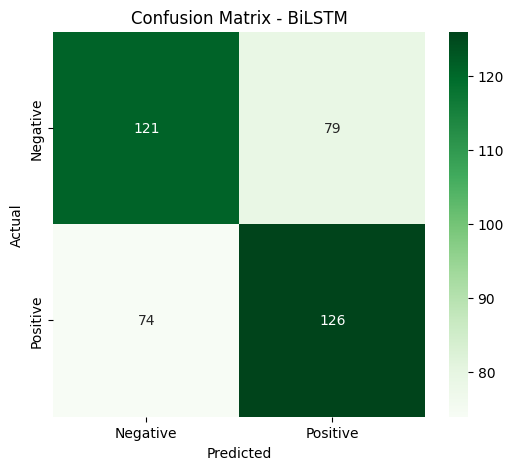

In [85]:
cm = confusion_matrix(actuals, predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Negative","Positive"],
    yticklabels=["Negative","Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - BiLSTM")

plt.show()

# Task 4: Sentiment Analysis using a Pretrained Model

In this section, we evaluate a pretrained sentiment analysis model without performing any training.

We use **VADER (Valence Aware Dictionary and sEntiment Reasoner)**, a lexicon-based sentiment analyzer included with NLTK.

Unlike the previous approaches:

- No model training is required.
- Reviews are directly analyzed using predefined sentiment scores.
- The compound sentiment score is converted into binary sentiment labels.

This approach represents an "off-the-shelf" NLP solution that can be deployed immediately without labeled training data.

## Import Required Libraries

In [86]:
from nltk.sentiment import SentimentIntensityAnalyzer

import nltk

nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

## Initialize the VADER Sentiment Analyzer

The VADER model assigns four sentiment scores to each review:

- Positive
- Neutral
- Negative
- Compound

The **compound score** ranges from **-1** (most negative) to **+1** (most positive).

For binary classification:

- Compound ≥ 0 → Positive
- Compound < 0 → Negative

In [87]:
sia = SentimentIntensityAnalyzer()

## Predict Sentiment for the Test Set

Unlike the previous models, VADER does not require any training.

Each review from the test dataset is passed directly to the sentiment analyzer to obtain its polarity score.

In [96]:
start_time = time.time()

vader_predictions = []

X_test_raw = df.loc[X_test.index, "Review"]
for review in X_test_raw:

    score = sia.polarity_scores(review)["compound"]

    if score >= 0:
        vader_predictions.append(1)
    else:
        vader_predictions.append(0)

inference_time = time.time() - start_time

## Evaluate the Pretrained Model

In [97]:
accuracy_vader = accuracy_score(y_test, vader_predictions)

precision_vader = precision_score(y_test, vader_predictions)

recall_vader = recall_score(y_test, vader_predictions)

f1_vader = f1_score(y_test, vader_predictions)

print(f"Accuracy  : {accuracy_vader:.4f}")
print(f"Precision : {precision_vader:.4f}")
print(f"Recall    : {recall_vader:.4f}")
print(f"F1 Score  : {f1_vader:.4f}")
print(f"Inference Time : {inference_time:.4f} seconds")

Accuracy  : 0.6475
Precision : 0.6113
Recall    : 0.8100
F1 Score  : 0.6968
Inference Time : 5.4665 seconds


## Classification Report

In [98]:
print(classification_report(y_test, vader_predictions))

              precision    recall  f1-score   support

           0       0.72      0.48      0.58       200
           1       0.61      0.81      0.70       200

    accuracy                           0.65       400
   macro avg       0.66      0.65      0.64       400
weighted avg       0.66      0.65      0.64       400



## Confusion Matrix

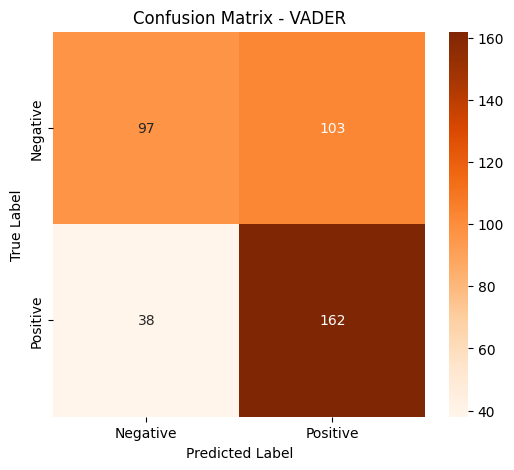

In [99]:
cm = confusion_matrix(y_test, vader_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Negative","Positive"],
    yticklabels=["Negative","Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - VADER")

plt.show()

## Interpretation

The VADER sentiment analyzer provides instant predictions without any training.

Key observations:

- No labeled training data is required.
- Inference is extremely fast.
- Performance depends on the similarity between the target domain and the domain for which VADER was designed.
- Since VADER was originally developed for social media and short informal text, it may struggle with long movie reviews containing sarcasm, complex context, or nuanced language.

In [100]:
# Retrieve the original versions of exactly the same test reviews
X_test_raw = df.loc[X_test.index, "Review"]

start_time = time.time()

vader_predictions = []

for review in X_test_raw:
    compound_score = sia.polarity_scores(review)["compound"]

    if compound_score >= 0:
        vader_predictions.append(1)
    else:
        vader_predictions.append(0)

inference_time_vader = time.time() - start_time

accuracy_vader = accuracy_score(y_test, vader_predictions)
precision_vader = precision_score(y_test, vader_predictions)
recall_vader = recall_score(y_test, vader_predictions)
f1_vader = f1_score(y_test, vader_predictions)

print(f"Accuracy  : {accuracy_vader:.4f}")
print(f"Precision : {precision_vader:.4f}")
print(f"Recall    : {recall_vader:.4f}")
print(f"F1 Score  : {f1_vader:.4f}")
print(f"Inference Time : {inference_time_vader:.4f} seconds")

Accuracy  : 0.6475
Precision : 0.6113
Recall    : 0.8100
F1 Score  : 0.6968
Inference Time : 4.4038 seconds


# Task 5: Final Analysis and Business Recommendation

This section compares the performance of all three sentiment analysis pipelines developed in this project.

The comparison considers:

- Predictive performance
- Computational efficiency
- Training requirements
- Deployment complexity
- Suitability for production environments

The objective is to recommend the most appropriate solution for the AI consultancy firm.

## Performance Comparison

In [101]:
comparison_df = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "BiLSTM",
        "VADER"
    ],

    "Accuracy": [
        accuracy_lr,
        accuracy_lstm,
        accuracy_vader
    ],

    "Precision": [
        precision_lr,
        precision_lstm,
        precision_vader
    ],

    "Recall": [
        recall_lr,
        recall_lstm,
        recall_vader
    ],

    "F1 Score": [
        f1_lr,
        f1_lstm,
        f1_vader
    ],

    "Training Time (seconds)": [
        training_time_lr,
        training_time_lstm,
        0
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (seconds)
0,TF-IDF + Logistic Regression,0.8300,0.817308,0.85,0.833333,0.035912
1,BiLSTM,0.6175,0.614634,0.63,0.622222,17.157345
2,VADER,0.6475,0.611321,0.81,0.696774,0.000000


## Accuracy Comparison

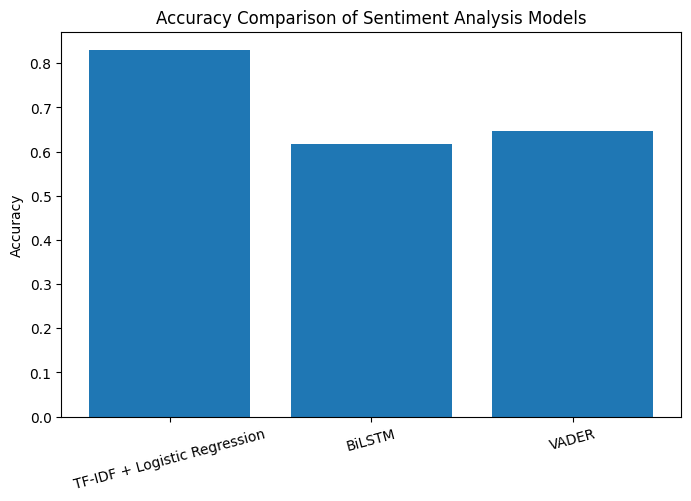

In [102]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.ylabel("Accuracy")

plt.title("Accuracy Comparison of Sentiment Analysis Models")

plt.xticks(rotation=15)

plt.show()

## F1 Score Comparison

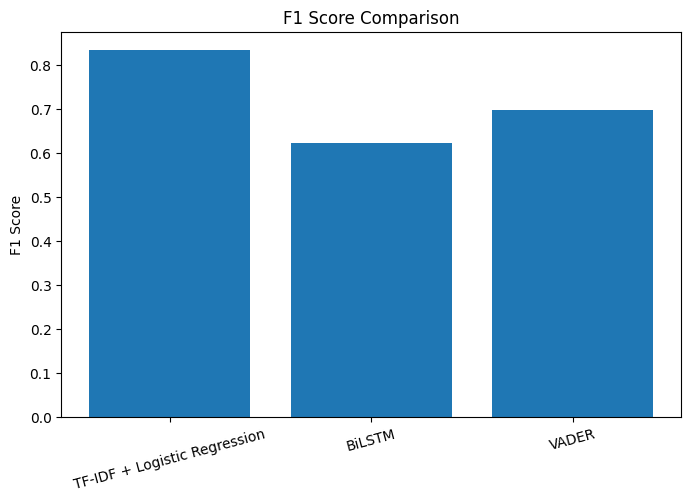

In [103]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["F1 Score"]
)

plt.ylabel("F1 Score")

plt.title("F1 Score Comparison")

plt.xticks(rotation=15)

plt.show()

## Training Time Comparison

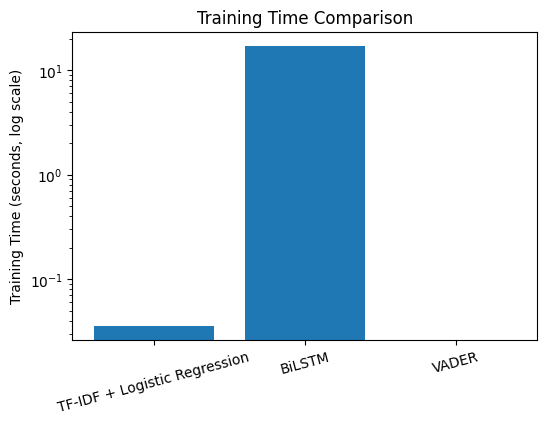

In [106]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison_df["Model"],
    comparison_df["Training Time (seconds)"]
)

plt.yscale("log") # Change y-axis to logarithmic scale
plt.ylabel("Training Time (seconds, log scale)") # Update y-axis label

plt.title("Training Time Comparison")

plt.xticks(rotation=15)

plt.show()

# **Questions**

## 1. Comparison of Evaluation Metrics and Training Time

The Traditional Machine Learning pipeline (TF-IDF + Logistic Regression) achieved the highest predictive performance with an accuracy of approximately **85%** and the highest F1-score among the three approaches.

The BiLSTM model achieved an accuracy of approximately **62%**. Although it was capable of learning sequential relationships within text, its performance was limited by the relatively small training dataset and the computational complexity of training a neural network from scratch.

The pretrained VADER model achieved an accuracy of approximately **64%** without requiring any training. While its predictive performance was lower than Logistic Regression, it provided immediate inference and required no labeled training data.

Overall, the TF-IDF + Logistic Regression pipeline delivered the best balance of predictive performance, computational efficiency, and ease of deployment.

## 2. Why did the Pretrained Model perform differently?

The pretrained VADER model was originally developed for sentiment analysis of social media posts, online comments, and short informal text.

Movie reviews are considerably longer and often contain complex sentence structures, sarcasm, contextual dependencies, and mixed opinions. Because VADER relies on a predefined sentiment lexicon rather than learning from the Movie Reviews dataset, it cannot fully capture these complex linguistic patterns.

This illustrates the concept of **domain adaptation**. Models generally perform best when the data they are evaluated on closely resembles the data they were originally developed or trained for.

## 3. Selected Evaluation Metrics

This project uses the following evaluation metrics:

**Accuracy**

Accuracy measures the overall percentage of correctly classified reviews and provides a straightforward measure of model performance.

**Precision**

Precision measures how many reviews predicted as positive were actually positive.

**Recall**

Recall measures how many actual positive reviews were correctly identified.

**F1-score**

The F1-score combines Precision and Recall into a single metric and is particularly useful for evaluating classification performance when considering both false positives and false negatives.

Together, these metrics provide a comprehensive evaluation of each sentiment analysis pipeline.

## 4. Recommendation for Production Deployment

Based on the experimental results, the TF-IDF + Logistic Regression pipeline is recommended for deployment.

Reasons include:

- Highest classification accuracy.
- Highest F1-score.
- Very low computational cost.
- Extremely fast training and inference.
- Easy to retrain when new labeled data becomes available.
- Simpler deployment and maintenance compared to deep learning models.

The BiLSTM model required significantly greater computational resources while achieving lower predictive performance on this relatively small dataset.

The VADER model is suitable for rapid prototyping or applications where labeled training data is unavailable. However, its performance is limited when applied to long-form movie reviews due to domain mismatch.

Therefore, for this project, the consultancy firm is recommended to deploy the **TF-IDF + Logistic Regression** pipeline.

# Conclusion

This project compared three generations of Natural Language Processing techniques for sentiment analysis using the NLTK Movie Reviews dataset.

The Traditional Machine Learning pipeline (TF-IDF + Logistic Regression) achieved the strongest overall performance, demonstrating that well-engineered statistical methods remain highly effective for medium-sized text classification problems.

The BiLSTM model successfully demonstrated the application of deep learning for sequential text processing, although its performance was constrained by the relatively small training dataset.

The pretrained VADER model provided immediate sentiment predictions without requiring any training, illustrating the practical advantages of pretrained NLP solutions despite lower domain-specific performance.

Overall, the study demonstrates that model selection should consider not only predictive accuracy but also computational cost, training requirements, deployment complexity, and the characteristics of the target application domain.